In [17]:
from pathlib import Path
import sys

CODE_DIR = Path("../../../code").resolve()
sys.path.insert(0, str(CODE_DIR))

from loaders.NegativeMiner import NegativeMiner
from loaders.Tiler import DataSource

In [18]:
dem_path = '/Users/willmcmahon/Documents/PhD/SCDs/DEMs/Italy/Merged.tif'
out_path = Path('/Users/willmcmahon/Documents/PhD/SCDs/scd-detection/data/PostIRP/dataset/out')

In [19]:
miner = NegativeMiner(dem=DataSource.from_tiff_utm(dem_path, native_res=10), resolutions = [3.5, 4, 4.5, 5.5, 6.5, 24, 27.5, 30], region='Italy', NODATA=0)

free area: 11,419,059,600 m^2 (114,190,596 px, 100.0% of DEM)

res  3.50m  tiles = 2489.0
res  4.00m  tiles = 1905.0
res  4.50m  tiles = 1505.0
res  5.50m  tiles = 1008.0
res  6.50m  tiles = 721.0
res 24.00m  tiles = 52.0
res 27.50m  tiles = 40.0
res 30.00m  tiles = 33.0


In [20]:
# counts

counts = {3.5: 10, 4: 10, 4.5: 10, 5.5: 10, 6.5: 10, 24: 5, 27.5: 5, 30: 5}

In [21]:
miner.generate_tiles(out_path, counts=counts)

3.50m: placed 10/2489, candidates exhausted
4.00m: placed 10/1905, candidates exhausted
4.50m: placed 10/1505, candidates exhausted
5.50m: placed 10/1008, candidates exhausted
6.50m: placed 10/721, candidates exhausted
24.00m: placed 5/52, candidates exhausted
27.50m: placed 5/40, candidates exhausted
30.00m: placed 4/33, candidates exhausted
exporting 351249_4666181_353041_4667973 at 3.50m
exporting 265299_4746656_267091_4748448 at 3.50m
exporting 279668_4726954_281460_4728746 at 3.50m
exporting 333266_4693182_335058_4694974 at 3.50m
exporting 315285_4730597_317077_4732389 at 3.50m
exporting 272547_4691067_274339_4692859 at 3.50m
exporting 340673_4660625_342465_4662417 at 3.50m
exporting 291948_4685626_293740_4687418 at 3.50m
exporting 266884_4743171_268932_4745219 at 4.00m
exporting 347075_4699924_349123_4701972 at 4.00m
exporting 299703_4728648_301751_4730696 at 4.00m
exporting 320582_4663616_322630_4665664 at 4.00m
exporting 291502_4728707_293550_4730755 at 4.00m
exporting 283623_4

# view tiles

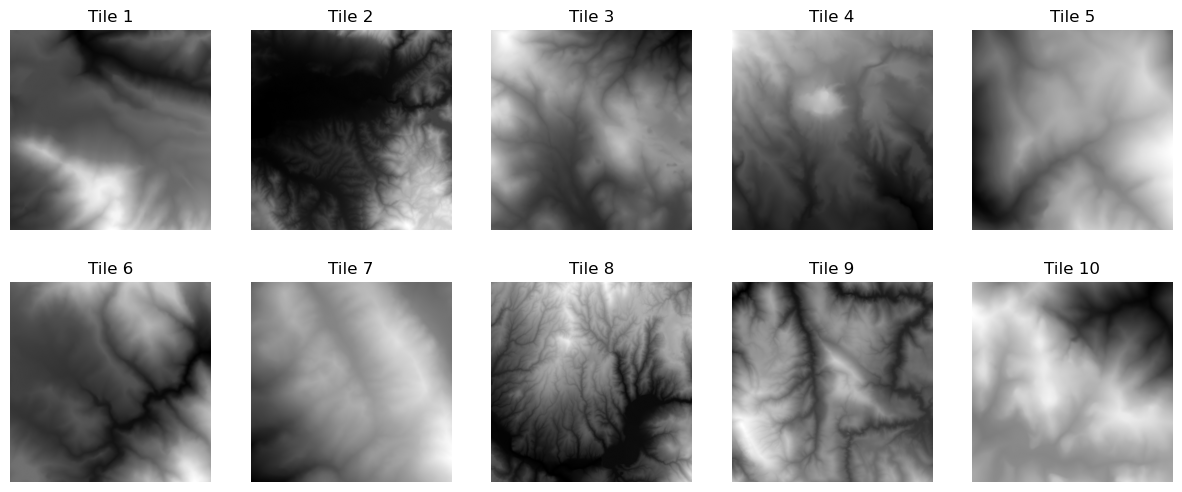

In [22]:
import glob 
import numpy as np
import matplotlib.pyplot as plt

paths = Path(out_path).glob('*.npz')
tiles = []

for p in paths:
    data = np.load(p)
    tiles.append(data['image'])

to_plot = tiles[20:30]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(to_plot[i][0], cmap='gray')
    ax.set_title(f'Tile {i+1}')
    ax.axis('off')  